# [Ulsan] DATATHON - COVID-19 Group 2


![Fuckyou.png](https://github.com/Noah-Junseo/AIFFEL_DATATHON/blob/main/Fuckyou.png?raw=true)


### Subject : Analysis of whether critical and death reduction is related to tertiary vaccination or virus.




### Table of Contents

#### 1. Introduction
- What are coronaviruses?
- News of Covid_19

#### 2. Data_set

#### 3. Data Analysis
- Geospatial visualization 
- Comparing the status of confirmed cases and vaccination status
- Trends according to all confirmed patients and each virus type
- Comparing the status of 2nd and 3rd vaccinations with the status of general adverse reactions.
- Comparison of vaccination status and severe and death status.
- The cause of death announced by the National Statistical Office.
- Comparison of deaths from COVID-19 with deaths in general.
- Comparison of the number of tertiary vaccinations and general deaths.
- Correlation between secondary and tertiary inoculations and severe abnormalities.

#### 4. Conclusion

#### 5. References

# 1. Introduction
## 1-1 What are coronaviruses?

![Covid19.png](https://github.com/Noah-Junseo/AIFFEL_DATATHON/blob/main/Covid19.png?raw=true)

Coronaviruses (CoV) are a large family of viruses that cause illnesses ranging from the common cold to more severe diseases. A novel coronavirus (nCoV) is a new strain that has not been previously identified in humans.

First reported in Wuhan, China on December 31, 2019, the virus is characterized by its ability to mutate easily into various forms.

**Major causes of death**: Analysis of deceased patients showed the most common comorbidities were hypertension (68.7%), diabetes (47.6%), and chronic lung disease (36.6%). These comorbidities, along with dementia, cancer, chronic kidney disease, and chronic liver disease, were identified as significant risk factors for COVID-19 mortality.

**Major vaccine side effects**: Anaphylaxis, Thrombosis with thrombocytopenia syndrome (TTS) after Johnson & Johnson's Janssen, Guillain-Barré Syndrome, Myocarditis and pericarditis, death

Major adverse reactions occurred in 0.4–0.6% of vaccinated individuals (1% for Moderna).

The government has mandated the 3rd dose, asserting vaccine safety, and has begun administering 4th doses. Whether the 4th dose will be mandated for the general adult population remains uncertain.


## 1-2 News of Covid_19


1) March 2020: WHO declared COVID-19 a pandemic

2) October 2020: First Delta variant case in India (reported ~80–90% infection prevention efficacy with 2 doses at the time)

3) February 2021: Vaccination began in South Korea

4) June 2021: Delta variant entered South Korea; 3rd dose considered

5) October 2021: 3rd dose began for high-risk groups, expanded to ages 18–49 by late November

6) October 2021: 2nd dose rate reached 70% (age 18+); phased return to normalcy announced

7) Early December 2021: First Omicron case in South Korea; government actively recommended 3rd dose

8) Late February 2022: 4th dose began for immunocompromised, then expanded to ~500K residents and staff in long-term care hospitals and facilities


## 2. Data_set

###### 1. Vaccination Status & Post-Vaccination Confirmed Cases (Feb 26, 2021 – Mar 6, 2022)

- case.csv (daily), vaccin_m (2nd/3rd dose, monthly)

- Columns: Date, total_1 (1st dose completed), total_2 (2nd dose completed), total_3 (3rd dose completed), confirmed cases by dose

- Confirmed cases by vaccine type: Pfizer_1–3, Moderna_1–3, Astra_1–3, Janssen_12/3, Nova_1–3, Other_1–3



###### 2. Confirmed Cases (Jan 20, 2020 – Feb 27, 2022)

- 2-1. By origin (domestic + imported), deaths / corona_death.csv
  - Columns: Date, Total, Korea, etc (imported), Death

- 2-2. By age group (10-year intervals) / age.csv
  - Columns: Date, Total, 0s, 10s, 20s, 30s, 40s, 50s, 60s, 70s, 80s (80+)

- 2-3. By gender / gender.csv
  - Columns: Date, Total, M (male), F (female)

- 2-4. By province and quarantine / province.csv
  - Columns: Date, Total, 17 provinces (Seoul, Busan, Daegu, Incheon, Gwangju, Daejeon, Ulsan, Sejong, Gyeonggi, Gangwon, Chungbuk, Chungnam, Jeonbuk, Jeonnam, Gyeongbuk, Gyeongnam, Jeju), Other (quarantine)



###### 3. Delta & Omicron Detection Status – virus_detection.csv (Oct 2021 – Jan 2022, monthly)

- Columns: weekend (week), delta, omicron, omicron_BA.2 (Omicron subvariant)



###### 4. Suspected Adverse Event Reports – SideEffect.csv

- Rows: Oct 28, 2021 (3rd dose start) / Dec 31 (week 43, Omicron start) / Feb 27 (current)

- Columns: Total_SideEffect, Mild, Death, AN (Anaphylaxis), Major
  - Note: Severe adverse events = Death + Anaphylaxis + Major adverse reactions



###### 5. Monthly Deaths – nomal_death.csv (Jan 2019 – Dec 2021)
- Rows: Month (1–12)
- Columns: Deaths by year (19y, 20y, 21y)


# 3. Data Analysis

## Geospatial visualization 

- [\[DS4C\]How tp use OSM Map feat Covid-19 ](https://corona.arrangy.com/ko/#KR)

- [\[DS4C\]OSM site](https://www.openstreetmap.org/#map=8/35.905/128.969&layers=H)


In [1]:
# !pip install folium  #시각화 라이브러리 설치
# !pip install OSM  Open Street Map 라이브러리 설치

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
# for dirname, _, filenames in os.walk('C:/Users/Noah/aiffel/datathon/kaggle'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
        
for dirname, _, filenames in os.walk('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import seaborn as sns
import matplotlib.pyplot as plt

import folium 
from folium import plugins
# from folium.plugins import HeatMap

import json 
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\34w_SideEffect.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\43w_SideEffect.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\52w_SideEffect.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\Age.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\Case.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\Cause_of_death.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\Covid_death.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\Gender.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet\Normal_death.csv
C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team 

In [3]:
patient = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/PatientInfo.csv')
# route = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/PatientRoute.csv')
province = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Province.csv')
age = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Age.csv')
case = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Case.csv')
N_death = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Normal_death.csv')
C_death = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Covid_death.csv')
gender = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Gender.csv')
SideEffect = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/SideEffect.csv')
Vd = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Virus_detection.csv')
cause = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/Cause_of_death.csv')
se34w = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/34w_SideEffect.csv')
se43w = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/43w_SideEffect.csv')
se52w = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/52w_SideEffect.csv')
vaccine_m = pd.read_csv('C:/Users/OHWONJIN/Desktop/.ipynb_checkpoints/[ㅤ]Team Final Covid-19 DataThon/CovidDataSet/vaccine_m.csv')

### 1) plotting just a map 
First, let's simply display a map.

```python
folium.Map([37,128]. zoom_start = 7, *tiles='Stamen Terrain'*)
folium.Map([37,128]. zoom_start = 7, *tiles='Stamen Toner'*)
```
There are several types of map, default, Stamen Terrain, and Stamen Toner. 

I prefer default option. 


In [6]:
m = folium.Map([36, 128], zoom_start=7) 

# you can try these options
# m = folium.Map([37, 128], zoom_start=7, tiles='Stamen Terrain') 
# m = folium.Map([37, 128], zoom_start=7, tiles='Stamen Toner') 

m

### Additional tool : Fullscreen, MousePosition(get coordinates)
Additional features: make the map fullscreen, and display coordinates on mouse hover.


In [7]:
m = folium.Map([36, 128], zoom_start=7) 

plugins.Fullscreen(position='topright',  # Full screen
                   title='Click to Expand', 
                   title_cancel='Click to Exit', 
                   force_separate_button=True).add_to(m)

plugins.MousePosition().add_to(m) ## you can easily get coordinates.


m

### 2) MarkerCluster : Lets see the number of regional confirmed patient.
Let's examine how many confirmed patients were reported in each region.


In [8]:
regional_patient = pd.merge(patient[['patient_id','confirmed_date','sex','age','province','city']],region[['province','city','latitude','longitude']], how = 'left', on = ['province','city'])
display(regional_patient.head())
print('There are a few missing values')
print('약간의 missing 값들이 있네요. 분석할 때 유의해야할 것 같습니다.')
display(regional_patient.isnull().sum() / regional_patient.shape[0])

,patient_id,confirmed_date,sex,age,province,city,latitude,longitude
0,1000000001,2020-01-23,male,50s,Seoul,Gangseo-gu,37.551166,126.849506
1,1000000002,2020-01-30,male,30s,Seoul,Jungnang-gu,37.606832,127.092656
2,1000000003,2020-01-30,male,50s,Seoul,Jongno-gu,37.572999,126.979189
3,1000000004,2020-01-30,male,20s,Seoul,Mapo-gu,37.566283,126.901644
4,1000000005,2020-01-31,female,20s,Seoul,Seongbuk-gu,37.589562,127.016700


There are a few missing values
약간의 missing 값들이 있네요. 분석할 때 유의해야할 것 같습니다.


patient_id        0.000000
confirmed_date    0.000749
sex               0.082418
age               0.119630
province          0.000000
city              0.019481
latitude          0.037962
longitude         0.037962
dtype: float64

### Capital Area (value of 724), including Seoul, Gyeonggi-do, Incheon etc., Gyeongsangbuk-do (972) look serious.

The Capital Area (Seoul, Gyeonggi, Incheon) and Gyeongsangbuk-do had the highest number of confirmed cases.


In [9]:
regional_count = regional_patient[['latitude','longitude']].dropna() # drop missing values

m = folium.Map([36, 128], zoom_start=7)

plugins.MousePosition().add_to(m) 

plugins.MarkerCluster(regional_count).add_to(m)

m

### 3) Make subgroups to plot : Female / Male
Let's create subgroups for female and male patients to visualize them separately on the map.



In [10]:
male_patient = regional_patient\
.query('sex in ("male")')[['latitude','longitude']].dropna()

female_patient = regional_patient\
.query('sex in ("female")')[['latitude','longitude']].dropna()


m = folium.Map([36, 128], zoom_start=7) 

initial = folium.plugins.MarkerCluster(control=False)

m.add_child(initial)


female_g = plugins.FeatureGroupSubGroup(initial, 'Female')
m.add_child(female_g)

male_g = plugins.FeatureGroupSubGroup(initial, 'Male') 
m.add_child(male_g)


plugins.MarkerCluster(female_patient).add_to(female_g)

plugins.MarkerCluster(male_patient).add_to(male_g)



folium.LayerControl(collapsed=False).add_to(m)

m

### 4) Make a Heat map : Instead of the number

Rather than displaying raw numbers, let's use a heat map to visually represent the density of confirmed cases by region.

**Heatmap parameter**

```python
folium.plugins.HeatMap(data, name=None, min_opacity=0.5, 
                       max_zoom=18, max_val=1.0, radius=25, blur=15, 
                       gradient=None, overlay=True, control=True, show=True, **kwargs)
```

```
- min_opacity (default 1.) – The minimum opacity the heat will start at.
- max_zoom (default 18) – Zoom level where the points reach maximum intensity (as intensity scales with zoom), equals maxZoom of the map by default
- max_val (float, default 1.) – Maximum point intensity
- radius (int, default 25) – Radius of each "point" of the heatmap
- blur (int, default 15) – Amount of blur
- gradient (dict, default None) – Color gradient config. e.g. {0.4: 'blue', 0.65: 'lime', 1: 'red'}
- overlay (bool, default True) – Adds the layer as an optional overlay (True) or the base layer (False).
- control (bool, default True) – Whether the Layer will be included in LayerControls.
- show (bool, default True) – Whether the layer will be shown on opening (only for overlays).
```

[Link](https://python-visualization.github.io/folium/plugins.html)



In [11]:
heat_data = regional_patient\
.groupby(['latitude','longitude'])['patient_id'].count().reset_index()\
.values\
.tolist()

m = folium.Map([36, 128], zoom_start=7)#, tiles = 'stamentoner')

folium.plugins.HeatMap(heat_data).add_to(m)

m

### In my opinion, I prefer Heatmap to MarkCluster. How about you? :-)

Personally, I find the heatmap more visually appealing. What do you think?


### Additional try : MarkCluster Layer On the Heatmap Layer.

Sometimes, we need to plot several statistics on only one map. (Multivariate)

So I tried combining Heatmap and MarkCluster on a single map.



In [12]:
heat_data = region[['latitude','longitude','nursing_home_count']].values.tolist() # nursing home count 

mark_data = regional_patient[['latitude','longitude']].dropna() # drop missing values

m = folium.Map([36, 128], zoom_start=7)

plugins.MarkerCluster(mark_data).add_to(m) # Layer 1

folium.plugins.HeatMap(heat_data, max_opacity = 0.3).add_to(m) # Layer 2

m

### Doesn't look good. 

The combined visualization doesn't look great.


### 5) Heatmap with time : time series heat map

```python
folium.plugins.HeatMapWithTime(data, index=None, name=None, 
                               radius=15, min_opacity=0, max_opacity=0.6, 
                               scale_radius=False, gradient=None, 
                               use_local_extrema=False, auto_play=False, 
                               display_index=True, index_steps=1, min_speed=0.1, 
                               max_speed=10, speed_step=0.1, position='bottomleft', 
                               overlay=True, control=True, show=True)
```

**Parameter** what i find important
```
data – The points you want to plot. The outer list corresponds to the various time steps in sequential order. (weight is in (0, 1] range and defaults to 1 if not specified for a point)

index  – the same length as data, or is replaced by a simple count if not specified.

radius (default 15.) – The radius used around points for the heatmap.

min_opacity (default 0) – The minimum opacity for the heatmap.

max_opacity (default 0.6) – The maximum opacity for the heatmap.

scale_radius (default False) – Scale the radius of the points based on the zoom level.

auto_play (default False) – Automatically play the animation across time.
```

[More](https://python-visualization.github.io/folium/plugins.html)

In [13]:
#prepare data

regional_patient_bytime = regional_patient\
.groupby(['confirmed_date','latitude','longitude'])['patient_id'].count().reset_index()\
.sort_values(by = 'confirmed_date')

date_rng = pd.date_range(regional_patient_bytime['confirmed_date'].min(), regional_patient_bytime['confirmed_date'].max())
date_rng = [str(i)[:10] for i in date_rng]

all_date_region = pd.DataFrame({'confirmed_date' : np.repeat(date_rng,region[['latitude','longitude']].drop_duplicates().shape[0]),
              'latitude' : np.tile(list(region['latitude'].drop_duplicates()), len(date_rng)),
              'longitude' : np.tile(list(region['longitude'].drop_duplicates()), len(date_rng))})

all_date_region = pd.merge(all_date_region, regional_patient_bytime, on = ['confirmed_date','latitude','longitude'], how = 'left').fillna(0)
all_date_region['cumsum'] = all_date_region.groupby(['latitude','longitude'])['patient_id'].cumsum()

all_date_region = all_date_region[all_date_region['cumsum'] != 0]

time_index, data = [], []

for date in all_date_region['confirmed_date'].unique():
    time_index += [date[6:].replace('-','/')]
    temp_list = all_date_region.query('confirmed_date == @date')[['latitude','longitude','cumsum']].values.tolist()
    data += [temp_list]
    del temp_list

### HeatMapWithTime needs this type of input data.


In [14]:
data[:5], time_index[:5]

([[[37.551166, 126.849506, 1.0]],
  [[37.551166, 126.849506, 1.0]],
  [[37.551166, 126.849506, 1.0]],
  [[37.551166, 126.849506, 1.0], [37.658363, 126.831961, 1.0]],
  [[37.551166, 126.849506, 1.0],
   [37.658363, 126.831961, 1.0],
   [36.992293, 127.112709, 1.0]]],
 ['1/23', '1/24', '1/25', '1/26', '1/27'])

In [15]:
# make a map
    
m = folium.Map([36, 128], zoom_start=7)#, tiles = 'Mapbox Bright')

hm = folium.plugins.HeatMapWithTime(data, index=time_index, auto_play=False, min_opacity=0.3, radius = 25, )

hm.add_to(m)

for bottom, click in zip([60,90,120,150,180],['Loop','Forward','Play','Reverse','Backward']):
    
    # Thank you for html code. https://www.kaggle.com/poonsfc5/ds4c-covid-19-in-korea-eda-with-geo-data
    name = '''
            <div style="position: fixed; bottom: '''+str(bottom)+'''px; left: 50px; width: 100px; height: 29px; 
                        background-color: white; border:1px solid grey; z-index:9999; font-size:11px;text-align:center;"
                        >&nbsp; <br><b>Click : '''+ click +'''</b></div>'''  

    m.get_root().html.add_child(folium.Element(name))

m

### 6) Make Circles with timebar : Timestamped Geojson

```python
TimestampedGeoJson(data, transition_time=200, loop=True, auto_play=True, 
                   add_last_point=True, period='P1D', min_speed=0.1, max_speed=10, 
                   loop_button=False, date_options='YYYY-MM-DD HH:mm:ss', 
                   time_slider_drag_update=False, duration=None)
```

parameter i find important
```
period (str, default "P1D") –  ‘P1M’ 1/month, ‘P1D’ 1/day, ‘PT1H’ 1/hour, and ‘PT1M’ 1/minute
```

[more](https://python-visualization.github.io/folium/plugins.html)

In [16]:
# prepare data
df_dropna = regional_patient.dropna()
df_dropna['timestamp'] = [i+'T00:00:00' for i in df_dropna['confirmed_date']]

points = []
for date in sorted(df_dropna['confirmed_date'].unique()):
    temp = df_dropna.query('confirmed_date == @date')
    
    temp_dict = {}
    temp_dict['coordinates'] = temp[['longitude','latitude']].values.tolist()
    temp_dict['dates'] = temp['timestamp'].values.tolist()
    
    points += [temp_dict]

features = [ { 'type': 'Feature', 
                  'geometry': { 'type': 'MultiPoint', 
                               'coordinates': point['coordinates'], }, 
                  'properties': { 'times': point['dates'],
                                 'icon' : 'circle'}
             } for point in points ] 

### TimestampedGeoJson needs this type of input data.

In [17]:
features[:3]

[{'type': 'Feature',
  'geometry': {'type': 'MultiPoint', 'coordinates': [[126.849506, 37.551166]]},
  'properties': {'times': ['2020-01-23T00:00:00'], 'icon': 'circle'}},
 {'type': 'Feature',
  'geometry': {'type': 'MultiPoint', 'coordinates': [[126.831961, 37.658363]]},
  'properties': {'times': ['2020-01-26T00:00:00'], 'icon': 'circle'}},
 {'type': 'Feature',
  'geometry': {'type': 'MultiPoint', 'coordinates': [[127.112709, 36.992293]]},
  'properties': {'times': ['2020-01-27T00:00:00'], 'icon': 'circle'}}]

In [18]:
m = folium.Map( location=[36, 128], zoom_start=7 )

plugins.TimestampedGeoJson({ 
    'type': 'FeatureCollection', 
    'features': features, 
}, period='P1D', auto_play = False).add_to(m)

m

There is some difference between Male and Female.
But, it is difficult to be considered that Female is more vulnerable to CVD-19 than male.


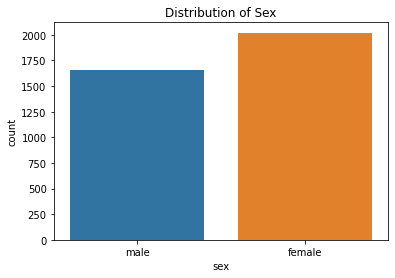

In [19]:
print('There is some difference between Male and Female.')
print('But, it is difficult to be considered that Female is more vulnerable to CVD-19 than male.')

sns.countplot(patient['sex'])
plt.title('Distribution of Sex')
plt.show()

In [20]:
# province

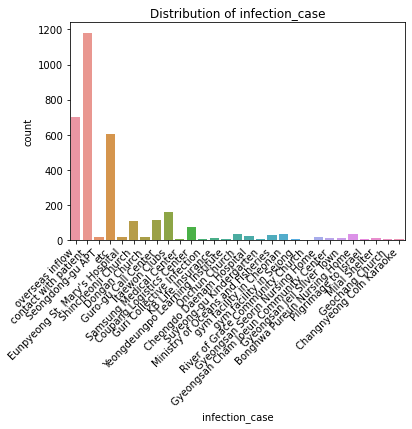

In [21]:
ax = sns.countplot(patient['infection_case'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Distribution of infection_case')
plt.show()

As you can see Capital area, Daegu, and Gyeongsangbuk-do rank top 3.


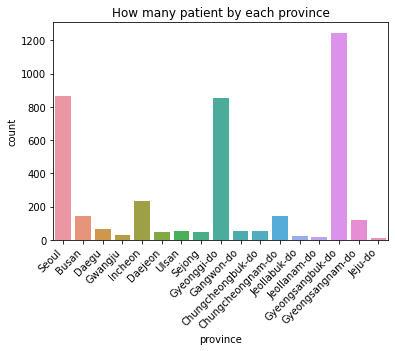

In [22]:
print('As you can see Capital area, Daegu, and Gyeongsangbuk-do rank top 3.')
ax = sns.countplot(patient['province'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('How many patient by each province')
plt.show()

In [15]:
# province에서 Date와 총 확진자수 Total열만 사용하므로 인덱스를 이용해서 데이터프레임 만들기 
province_T = province # 복사본 생성해놓고 
province_T = province_T.iloc[:,[0, 1]]
province_T

,Date,Total
0,20-01-20,1
1,20-01-21,0
2,20-01-22,0
3,20-01-23,0
4,20-01-24,1
...,...,...
765,22-02-23,171451
766,22-02-24,170009
767,22-02-25,165890
768,22-02-26,166207


In [16]:
case = case.sort_values('Date')
case

,Date,total_1,total_2,total_3,Pfizer_1,Pfizer_2,Pfizer_3,Moderna_1,Moderna_2,Moderna_3,...,Astra_2,Astra_3,Janssen_12,Janssen_3,Nova_1,Nova_2,Nova_3,Other_1,Other_2,Other_3
373,21-02-26,37380,10312,0,5057,2756,0,7009,4402,0,...,3,0,42,0,0,0,0,4673,3109,0
372,21-02-27,1717,187,0,469,74,0,81,92,0,...,0,0,2,0,0,0,0,42,19,0
371,21-02-28,1012,91,0,380,42,0,35,36,0,...,0,0,0,0,0,0,0,16,13,0
370,21-03-01,1904,227,0,458,70,0,136,55,0,...,0,0,4,0,0,0,0,111,98,0
369,21-03-02,66184,263,0,842,84,0,152,101,0,...,0,0,3,0,0,0,0,120,75,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,22-03-02,2211,4341,64893,1049,4132,46753,32,66,17267,...,0,0,6,31,1124,137,842,0,0,0
3,22-03-03,1996,4255,66443,990,3946,46703,33,190,18919,...,0,0,4,17,969,115,804,0,0,0
2,22-03-04,3499,7705,104826,2217,7281,70968,61,286,32757,...,0,0,10,19,1211,128,1082,0,0,0
1,22-03-05,2289,5589,52373,1795,5384,35855,21,149,16077,...,0,0,0,1,473,56,440,0,0,0


In [17]:
# Date, total2, total3 열 필요
case2 = case
case_T23 = case2.iloc[:,[0,2,3]]
case_T23

,Date,total_2,total_3
373,21-02-26,10312,0
372,21-02-27,187,0
371,21-02-28,91,0
370,21-03-01,227,0
369,21-03-02,263,0
...,...,...,...
4,22-03-02,4341,64893
3,22-03-03,4255,66443
2,22-03-04,7705,104826
1,22-03-05,5589,52373


In [18]:
# 위의 두 데이터프레임 병합(기본 교집합으로 병합됨)
confirmed_T = pd.merge(province_T, case_T23)
confirmed_T

,Date,Total,total_2,total_3
0,21-02-26,387,10312,0
1,21-02-27,415,187,0
2,21-02-28,355,91,0
3,21-03-01,355,227,0
4,21-03-02,344,263,0
...,...,...,...,...
362,22-02-23,171451,3674,109494
363,22-02-24,170009,10439,148027
364,22-02-25,165890,13908,227351
365,22-02-26,166207,8467,119499


### Comparing the status of confirmed cases and vaccination status

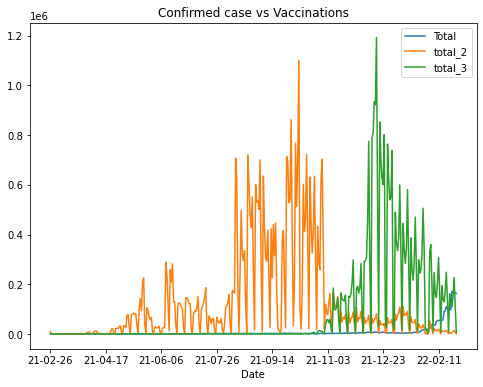

In [19]:
confirmed_T.plot(x='Date', y=['Total','total_2','total_3'], figsize=(8,6))
plt.title('Confirmed case vs Vaccinations')
plt.show()

- Although the number of 2nd and 3rd dose recipients (orange/green) increased significantly, the total number of confirmed cases showed an upward trend as of February 11.


- Despite rising vaccination rates, the number of confirmed cases did not decrease — rather, it continued to grow.


- Omicron detection rate: 1% in the 2nd week of December → 50% by the 4th week of January → 92% by the 1st week of February. The graph clearly shows that once Omicron became the dominant strain in February, confirmed cases surged dramatically.


- From December 18, the government restricted private gatherings to 4 people and limited operating hours for restaurants and cafes to 9–10 PM. However, these social distancing measures also proved ineffective.


### Trends according to all confirmed patients and each virus type

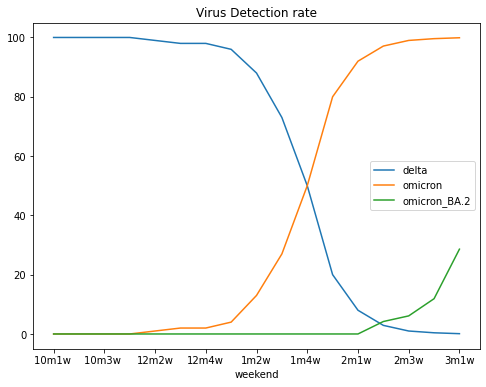

In [20]:
# 바이러스 별 검출률 
Vd.plot(x='weekend', y=['delta','omicron','omicron_BA.2'], figsize=(8,6))
plt.title('Virus Detection rate')
plt.show()

In [21]:
SideEffect_mild = SideEffect
SideEffect_mild = SideEffect.iloc[:,[0,1,2,3]]
SideEffect_mild

,Date,Total_Side_effect,Second_mild,Third_mild
0,21-10-28,338261,117300,82
1,21-12-31,411038,157463,15789
2,22-02-27,460006,167149,46572


In [22]:
SideEffect_mild.set_index('Date', inplace=True)
SideEffect_mild

,Total_Side_effect,Second_mild,Third_mild
Date,,,
21-10-28,338261,117300,82
21-12-31,411038,157463,15789
22-02-27,460006,167149,46572


### Comparing the status of 2nd and 3rd vaccinations with the status of general adverse reactions.

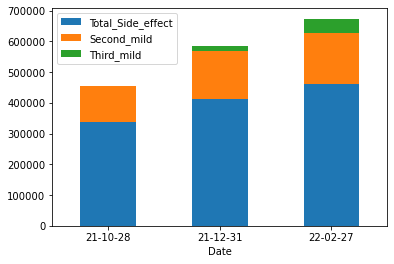

In [24]:
# 전체 이상 반응과 경증 이상반응보고 현황 비교 분석
SideEffect_mild.plot(kind='bar', stacked=True)
plt.xticks(rotation=0, fontsize=10)
plt.show()

#21년 10월 28일 : 3차 접종 시작 / 21년 12월 31일 : 오미크론 확산 시작 / 22년 2월 27일 : 현재

In [25]:
SideEffect

,Date,Total_Side_effect,Second_mild,Third_mild,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major
0,21-10-28,338261,117300,82,326,216,3140,0,0,1
1,21-12-31,411038,157463,15789,460,274,4207,118,41,401
2,22-02-27,460006,167149,46572,550,322,4720,304,96,1440


Note:

- Total_Side_effect includes all mild and severe adverse reactions from the 1st through 3rd doses.
- Second_mild: individuals who reported mild side effects after the 2nd dose; AN: those who reported anaphylaxis; Major: those who reported major adverse reactions.


In [26]:
SideEffect_Major = SideEffect
SideEffect_Major = SideEffect_Major.iloc[:,[0,4,5,6,7,8,9]]
SideEffect_Major.set_index('Date', inplace=True)
SideEffect_Major

,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major
Date,,,,,,
21-10-28,326,216,3140,0,0,1
21-12-31,460,274,4207,118,41,401
22-02-27,550,322,4720,304,96,1440


In [27]:
# Total_Side_effect 포함된 데이터프레임
SideEffect_Major_T = SideEffect
SideEffect_Major_T = SideEffect_Major_T.iloc[:,[0,1,4,5,6,7,8,9]]
SideEffect_Major_T.set_index('Date', inplace=True)
SideEffect_Major_T

,Total_Side_effect,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major
Date,,,,,,,
21-10-28,338261,326,216,3140,0,0,1
21-12-31,411038,460,274,4207,118,41,401
22-02-27,460006,550,322,4720,304,96,1440


### Comparison of vaccination status and severe and death status.

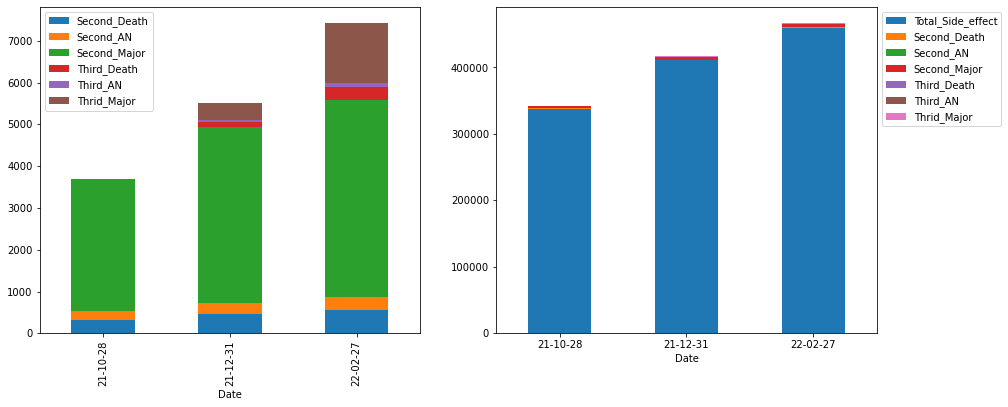

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2)
SideEffect_Major.plot(kind='bar', stacked=True, figsize=(15,6), ax=axes[0])
plt.xticks(rotation=0, fontsize=10)

SideEffect_Major_T.plot(kind='bar', stacked=True, figsize=(15,6), ax=axes[1])
plt.legend(bbox_to_anchor=(1,1))
plt.xticks(rotation=0, fontsize=10)
plt.show()

Looking at the right graph first, the 3rd-dose-related adverse reaction numbers are not conspicuous within the total reported adverse reactions (1st, 2nd, 3rd doses). However, when examining only the major adverse reactions closely, we can see an increase starting from December 31 (when the 3rd dose rate was declining), suggesting that severe illness and mortality associated with the 3rd vaccination dose did increase.

##### Oct 28, 2021: 3rd dose began / Dec 31, 2021: Omicron spread began & 3rd dose peak / Feb 27, 2022: Current


### The cause of death announced by the National Statistical Office.

#### total: overall mortality, hemo: blood-related deaths, circulatory: cardiovascular/cerebrovascular deaths, respiratory: respiratory-related deaths, PN: pneumonia, CLD: chronic lower respiratory disease


In [11]:
cause.set_index('year', inplace=True)
cause

,total,hemo,circulatory,respiratory,PN,CLD
year,,,,,,
2010,454.0,1.3,118.0,37.1,14.9,14.2
2019,523.9,1.9,122.7,71.4,45.1,12.0
2020,543.0,2.0,126.7,70.8,43.3,11.0


While the table above shows relatively high mortality rates for major causes of death, the data from the National Statistical Office includes not only health-related causes but also other factors, so the total value should be used for reference only.

As noted in the introduction, since the major causes of COVID-19 death are primarily related to infection, we should focus on circulatory (cardiovascular/cerebrovascular) and respiratory figures.

Cardiovascular disease has been the leading cause of death in South Korea, and these figures have been steadily increasing since 2010. Therefore, it is difficult to conclude that this increase is solely attributable to COVID-19.

* PN (pneumonia) and CLD (chronic lower respiratory disease) are included in the respiratory figures.

COVID-19 causes of death (research papers):
1) https://www.nature.com/articles/s41598-021-82862-5
2) https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7539724/


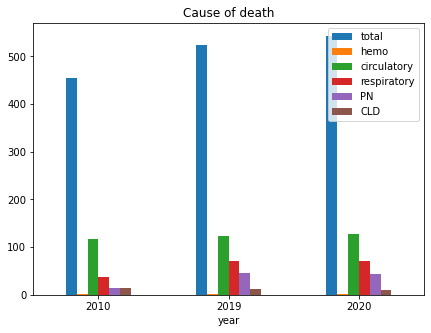

In [12]:
cause.plot(kind='bar', figsize=(7, 5))
plt.xticks(rotation=0, fontsize=10)
plt.title('Cause of death')
plt.show()

In [13]:
SideEffect_Major_T = SideEffect
# 필요한 열만 뽑기, 중증도 관련 열만 선택
SideEffect_Major_T = SideEffect_Major_T.iloc[:,[0,1,4,5,6,7,8,9]]
SideEffect_Major_T

,Date,Total_Side_effect,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major
0,21-10-28,338261,326,216,3140,0,0,1
1,21-12-31,411038,460,274,4207,118,41,401
2,22-02-27,460006,550,322,4720,304,96,1440


In [14]:
SE_Major = SideEffect_Major_T
SE_Major

,Date,Total_Side_effect,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major
0,21-10-28,338261,326,216,3140,0,0,1
1,21-12-31,411038,460,274,4207,118,41,401
2,22-02-27,460006,550,322,4720,304,96,1440


### Comparison of deaths from COVID-19 with deaths in general. 

In [15]:
N_death.rename(columns={'Death':'normal_death'},inplace = True)
C_death.rename(columns={'Death':'corona_death'},inplace = True)

In [16]:
#C_death.head()

In [17]:
#N_death.head()

In [18]:
death = pd.merge(N_death, C_death)
#death

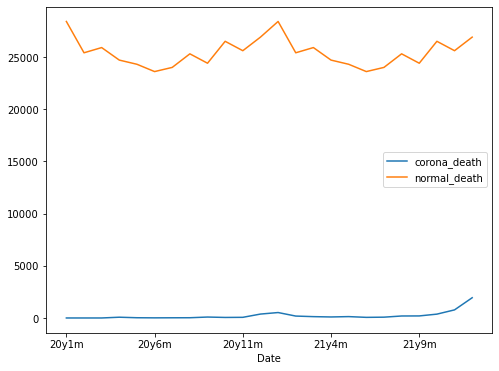

In [19]:
death.plot(x='Date', y=['corona_death','normal_death'],figsize=(8,6))
plt.show()

We compared general deaths (from the National Statistical Office) with COVID-19 deaths.

Considering the Delta variant period in 2020 (which had a higher fatality rate than Omicron) and the second half of 2021 when 3rd dose eligibility expired, the COVID-19 fatality rate was not significantly different from the general mortality rate, suggesting that the 3rd dose had no apparent effect.

While general and COVID-19 deaths appeared to trend upward in the second half of 2021, this coincided with the implementation of Phase 1 of the phased return to normalcy in November, when private gatherings expanded to 12 people. During this period, severe/critical patients doubled and hospital bed utilization rates rose from the 50% range to the 80% range — raising the possibility that this was due to the Delta variant's characteristics rather than vaccine inefficacy.


### Comparison of the number of tertiary vaccinations and general deaths.

In [31]:
comparison = pd.merge(N_death[['Date','normal_death']],vaccine_m[['Date','total_2','total_3']], how ='right', on = ['Date'])
comparison

,Date,normal_death,total_2,total_3
0,21y2m,25400.0,10590,0
1,21y3m,25900.0,28084,0
2,21y4m,24700.0,251537,2
3,21y5m,24300.0,1969558,5
4,21y6m,23600.0,2928442,28
5,21y7m,24000.0,2125368,101
6,21y8m,25300.0,8638554,758
7,21y9m,24400.0,9937895,1532
8,21y10m,26500.0,12952018,89833
9,21y11m,25600.0,2344089,89833


In [26]:
comparison1=comparison.drop(11)

In [27]:
comparison2 =comparison1.drop(12)
comparison2

,Date,normal_death,total_2,total_3
0,21y2m,25400.0,10590,0
1,21y3m,25900.0,28084,0
2,21y4m,24700.0,251537,2
3,21y5m,24300.0,1969558,5
4,21y6m,23600.0,2928442,28
5,21y7m,24000.0,2125368,101
6,21y8m,25300.0,8638554,758
7,21y9m,24400.0,9937895,1532
8,21y10m,26500.0,12952018,89833
9,21y11m,25600.0,2344089,89833


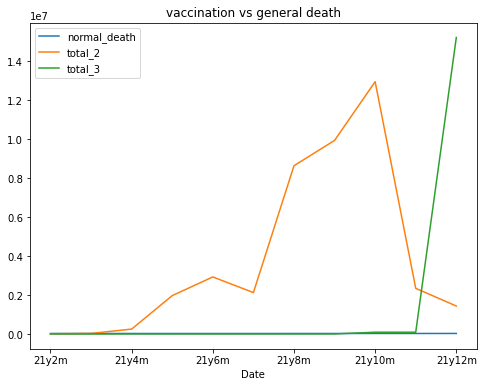

In [28]:
comparison2.plot(x='Date', y=['normal_death','total_2','total_3'],figsize=(8,6))
plt.title('vaccination vs general death')
plt.show()

The normal_death values are in the range of 20,000–30,000 per month,

while total_2 and total_3 values range from a minimum of 0 to a maximum of 15,223,627 (approximately 15 million).

Since the normal_death values appear flat compared to total_2 and total_3 due to the scale difference, we will use the Pearson correlation coefficient to examine the relationship.


In [29]:
comparison2.corr()

,normal_death,total_2,total_3
normal_death,1.000000,0.135263,0.560183
total_2,0.135263,1.000000,-0.177583
total_3,0.560183,-0.177583,1.000000


<AxesSubplot:>

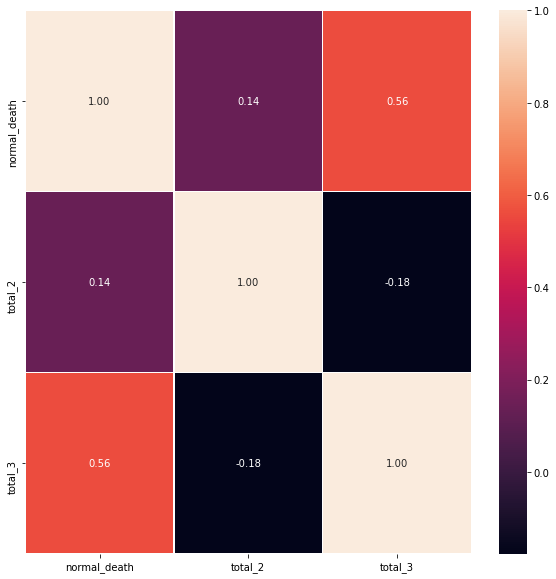

In [30]:
plt.figure(figsize=(10,10))
sns.heatmap(data = comparison2.corr(), annot=True, 
fmt = '.2f', linewidths=.5)

- The reason we compare vaccination with general deaths rather than COVID-19 deaths or hospital bed utilization rates is that, based on experience working at a public health center, the correlation between COVID-19 and severe/critical illness was not easily acknowledged. We also considered the possibility that the KDCA might have issued misleading reports to increase vaccination rates. Therefore, we compared against general mortality as a relatively more reliable indicator.



- According to the Pearson correlation coefficient above, 2nd-dose vaccination shows a negative correlation of -0.18 with general deaths, whereas 3rd-dose vaccination shows a low positive correlation coefficient of 0.56.


- An important consideration for this data: the dataset covers February 2021 through December 2021 (the National Statistical Office provides general mortality statistics only through 2021). Since the 3rd dose began in earnest in October in South Korea (peaking at approximately 140,000 doses in December, then declining to approximately 88,000 by January 2022), the observation period is insufficient to conclude that the 3rd dose reduced severe illness and mortality.


- Therefore, a more accurate comparison would require either cause-of-death statistics for the second half of 2021 or mortality data extending through 2022.


### Correlation between secondary and tertiary inoculations and severe abnormalities.

In [20]:
case2 = case
case_T23 = case2.iloc[:,[0,2,3]]
case_T23

,Date,total_2,total_3
0,22-03-06,194,1675
1,22-03-05,5589,52373
2,22-03-04,7705,104826
3,22-03-03,4255,66443
4,22-03-02,4341,64893
...,...,...,...
369,21-03-02,263,0
370,21-03-01,227,0
371,21-02-28,91,0
372,21-02-27,187,0


In [21]:
merge = pd.merge(SE_Major,case_T23,on='Date')

In [22]:
merge

,Date,Total_Side_effect,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major,total_2,total_3
0,21-10-28,338261,326,216,3140,0,0,1,624572,9938
1,21-12-31,411038,460,274,4207,118,41,401,58563,737969
2,22-02-27,460006,550,322,4720,304,96,1440,451,6086


In [23]:
merge.corr() 

,Total_Side_effect,Second_Death,Second_AN,Second_Major,Third_Death,Third_AN,Thrid_Major,total_2,total_3
Total_Side_effect,1.000000,1.000000,0.998317,0.996191,0.971132,0.980769,0.934692,-0.947077,0.107654
Second_Death,1.000000,1.000000,0.998289,0.996234,0.971014,0.980673,0.934517,-0.947235,0.108144
Second_AN,0.998317,0.998289,1.000000,0.989459,0.983330,0.990436,0.953731,-0.926869,0.049823
Second_Major,0.996191,0.996234,0.989459,1.000000,0.946633,0.960016,0.900138,-0.971460,0.193932
Third_Death,0.971132,0.971014,0.983330,0.946633,1.000000,0.999013,0.992502,-0.843162,-0.132611
Third_AN,0.980769,0.980673,0.990436,0.960016,0.999013,1.000000,0.986092,-0.866212,-0.088453
Thrid_Major,0.934692,0.934517,0.953731,0.900138,0.992502,0.986092,1.000000,-0.771120,-0.252770
total_2,-0.947077,-0.947235,-0.926869,-0.971460,-0.843162,-0.866212,-0.771120,1.000000,-0.421099
total_3,0.107654,0.108144,0.049823,0.193932,-0.132611,-0.088453,-0.252770,-0.421099,1.000000


<AxesSubplot:>

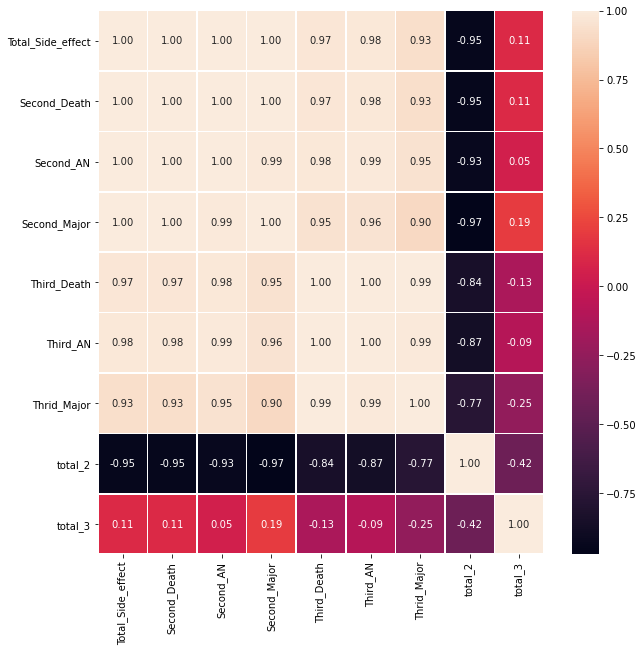

In [24]:
plt.figure(figsize=(10,10))
sns.heatmap(data = merge.corr(), annot=True, 
fmt = '.2f', linewidths=.5)

In the "Comparing the status of 2nd and 3rd vaccinations with the status of general adverse reactions" and "Comparison of vaccination status and severe and death status" graphs, we observed that adverse reaction reports increased with the 3rd dose compared to the 2nd dose. We therefore applied the Pearson correlation coefficient.

The data used above includes records through February 2022. While the 2nd dose shows a high correlation coefficient with adverse reactions, the 3rd dose shows a low correlation coefficient. Therefore, rather than hastily concluding that the 3rd dose caused more adverse reactions, further research in this area is needed. An additional step of identifying the specific factors causing adverse reactions after the 3rd dose and re-examining the correlation would be necessary.


# 4. Conclusion

- This COVID-19 data analysis focused on the relationship between 3rd-dose vaccination and severe illness/mortality rates, questioning the necessity of 3rd and 4th doses.


- While there are many internal and external factors to consider regarding infection, we examined the correlation between each dataset's output and the government's strongly advocated vaccination data. The Pearson correlation between 3rd-dose vaccination (total_3) and general deaths (normal_death) was 0.56, indicating a low correlation.


- When examining 3rd-dose vaccination and adverse reaction reports, the graphs showed an increase compared to the 2nd dose, but the Pearson correlation coefficient indicated a low correlation.



- Comparing mortality rates between 2019 and 2020 (during the more lethal Delta variant) using National Statistical Office data, mortality actually decreased.
  (A clearer picture regarding vaccine efficacy is expected once the cause-of-death data for 2021 becomes available from the National Statistical Office.)


- ### In conclusion, reductions in severe illness and mortality appear to be more attributable to Omicron variant characteristics and other factors rather than vaccine effectiveness. The 3rd and 4th booster doses were determined to be inappropriate based on the data examined.


 # 5. References
- https://www.cdc.gov/coronavirus/2019-ncov/vaccines/safety/adverse-events.html
- KDCA (Korea Disease Control and Prevention Agency): Press releases and COVID-19 news (mohw.go.kr)
- Public Data Portal: data.go.kr
- National Statistical Office (KOSTAT)
- https://www.notion.so/modulabs/31a6c3be51e54f2eb6b47084efdd3a48?v=c728d3b3ea364b29aaa14fcfcbc06dcd
- https://www.figma.com/file/8LsLrUmxhDaXlgjoQehwye/Covid-19-%5B%E3%85%A4%5D?node-id=141%3A81
- Pearson correlation coefficient: https://support.minitab.com/ko-kr/minitab/18/help-and-how-to/statistics/basic-statistics/how-to/correlation/interpret-the-results/key-results/

Reason for using OSM visualization

- [\[DS4C\]How to use OSM Map feat Covid-19 ](https://corona.arrangy.com/ko/#KR)

- [\[DS4C\]OSM site](https://www.openstreetmap.org/#map=8/35.905/128.969&layers=H)
